# News Dataset - Exploratory Data Analysis (EDA)

Exploratory analysis of the raw GDELT news article dataset across 20 stock tickers.

**Data source**: `gdelt_news_data/` directory  
**Columns**: `ticker, date, headline, source, url, language, sourcecountry, search_keyword`  
**Period**: October 2023 - October 2025

## 1. Imports and Data Loading

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 160

In [2]:
# Resolve data directory
BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "Raw_Data/gdelt_news_data").exists():
    BASE_DIR = BASE_DIR.parent

INPUT_DIR = BASE_DIR / "Raw_Data/gdelt_news_data"
print(f"Data directory: {INPUT_DIR}")

# Load all news CSVs into a single DataFrame
all_files = sorted(INPUT_DIR.glob("*_news.csv"))
print(f"Found {len(all_files)} news CSV files")

dfs = []
for f in all_files:
    df = pd.read_csv(f)
    dfs.append(df)

news = pd.concat(dfs, ignore_index=True)
news["date"] = pd.to_datetime(news["date"], errors="coerce")
news["date_only"] = news["date"].dt.date

print(f"\nTotal articles loaded: {len(news):,}")
news.head()

Data directory: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Raw_Data\gdelt_news_data
Found 20 news CSV files

Total articles loaded: 64,069


,ticker,date,headline,source,url,language,sourcecountry,search_keyword,date_only
0,AAPL,2023-10-10 06:15:00+00:00,Tesla Owners Are Using This iPhone 15 Pro Butt...,benzinga.com,https://www.benzinga.com/news/23/10/35154027/t...,English,United States,Apple Inc,2023-10-10
1,AAPL,2023-10-10 10:45:00+00:00,Why Munster Thinks Google Antitrust Lawsuit Ov...,benzinga.com,https://www.benzinga.com/analyst-ratings/analy...,English,United States,Apple Inc,2023-10-10
2,AAPL,2023-10-10 11:30:00+00:00,Best October Prime Day AirPods Deals 2023,forbes.com,https://www.forbes.com/sites/forbes-personal-s...,English,United States,iPhone Apple,2023-10-10
3,AAPL,2023-10-10 11:45:00+00:00,The Morning After : Our verdict on the Meta Qu...,engadget.com,https://www.engadget.com/the-morning-after-our...,English,Japan,iPhone Apple,2023-10-10
4,AAPL,2023-10-10 13:00:00+00:00,"Apple Stock Issues Include China , AI , Search...",barrons.com,https://www.barrons.com/articles/apple-stock-b...,English,China,Apple stock,2023-10-10


## 2. Dataset Overview

In [3]:
print("Shape:", news.shape)
print("\nColumn dtypes:")
print(news.dtypes)
print("\nMissing values:")
print(news.isnull().sum())
print("\nDuplicate rows:", news.duplicated().sum())

Shape: (64069, 9)

Column dtypes:
ticker                            str
date              datetime64[us, UTC]
headline                          str
source                            str
url                               str
language                          str
sourcecountry                     str
search_keyword                    str
date_only                      object
dtype: object

Missing values:
ticker            0
date              0
headline          0
source            0
url               0
language          0
sourcecountry     0
search_keyword    0
date_only         0
dtype: int64

Duplicate rows: 0


In [4]:
news.describe(include="all")

,ticker,date,headline,source,url,language,sourcecountry,search_keyword,date_only
count,64069,64069,64069,64069,64069,64069,64069,64069,64069
unique,20,NaN,52740,65,53148,1,7,66,796
top,NVDA,NaN,5 Things to Know Before the Stock Market Opens,finance.yahoo.com,https://www.cnbc.com/2025/10/26/here-are-the-3...,English,United States,Nvidia,2025-11-17
freq,9354,NaN,18,21318,11,64069,60359,7043,318
mean,NaN,2025-01-21 02:39:03.618599+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2023-10-10 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2024-05-21 19:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2025-02-13 04:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2025-10-20 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2025-12-31 23:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Article Counts by Ticker

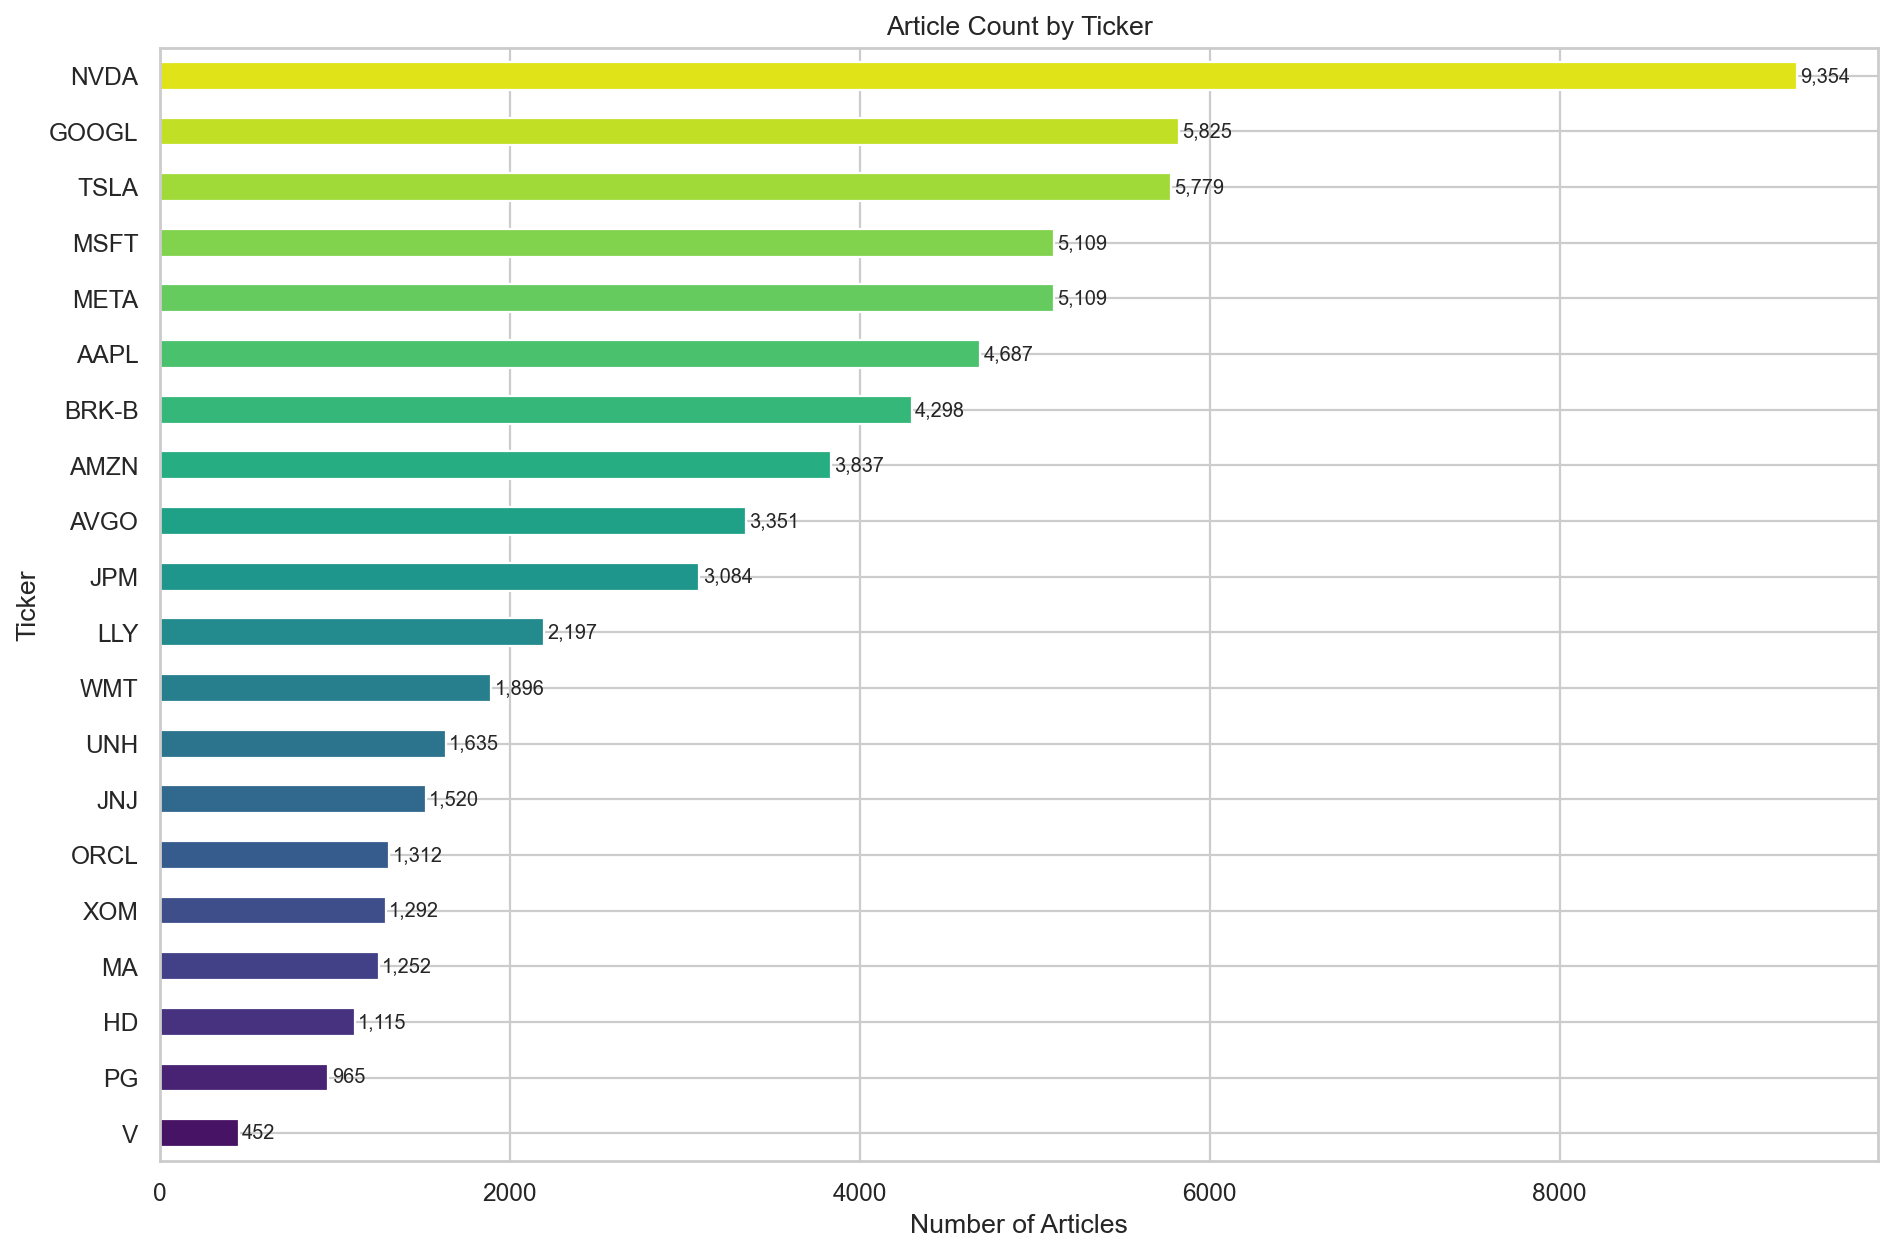


Mean: 3,203
Median: 2,640
Std Dev: 2,276


In [5]:
ticker_counts = news["ticker"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ticker_counts.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(ticker_counts)))
ax.set_xlabel("Number of Articles")
ax.set_ylabel("Ticker")
ax.set_title("Article Count by Ticker")

for i, v in enumerate(ticker_counts):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_news_by_ticker.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nMean: {ticker_counts.mean():,.0f}")
print(f"Median: {ticker_counts.median():,.0f}")
print(f"Std Dev: {ticker_counts.std():,.0f}")

## 4. Date Range and Temporal Coverage

In [6]:
# Date range per ticker
date_ranges = news.groupby("ticker")["date"].agg(["min", "max", "count"]).sort_values("count", ascending=False)
date_ranges.columns = ["Earliest", "Latest", "Count"]
display(date_ranges)

,Earliest,Latest,Count
ticker,,,
NVDA,2023-10-10 03:15:00+00:00,2025-12-31 23:30:00+00:00,9354
GOOGL,2023-10-10 05:00:00+00:00,2025-12-31 21:30:00+00:00,5825
TSLA,2023-10-10 04:45:00+00:00,2025-12-31 23:45:00+00:00,5779
MSFT,2023-10-10 20:30:00+00:00,2025-12-31 22:15:00+00:00,5109
META,2023-10-10 03:00:00+00:00,2025-12-31 23:45:00+00:00,5109
AAPL,2023-10-10 06:15:00+00:00,2025-12-31 18:15:00+00:00,4687
BRK-B,2023-10-10 01:00:00+00:00,2025-12-31 21:30:00+00:00,4298
AMZN,2023-10-10 01:00:00+00:00,2025-12-31 22:15:00+00:00,3837
AVGO,2023-10-10 18:30:00+00:00,2025-12-31 22:30:00+00:00,3351


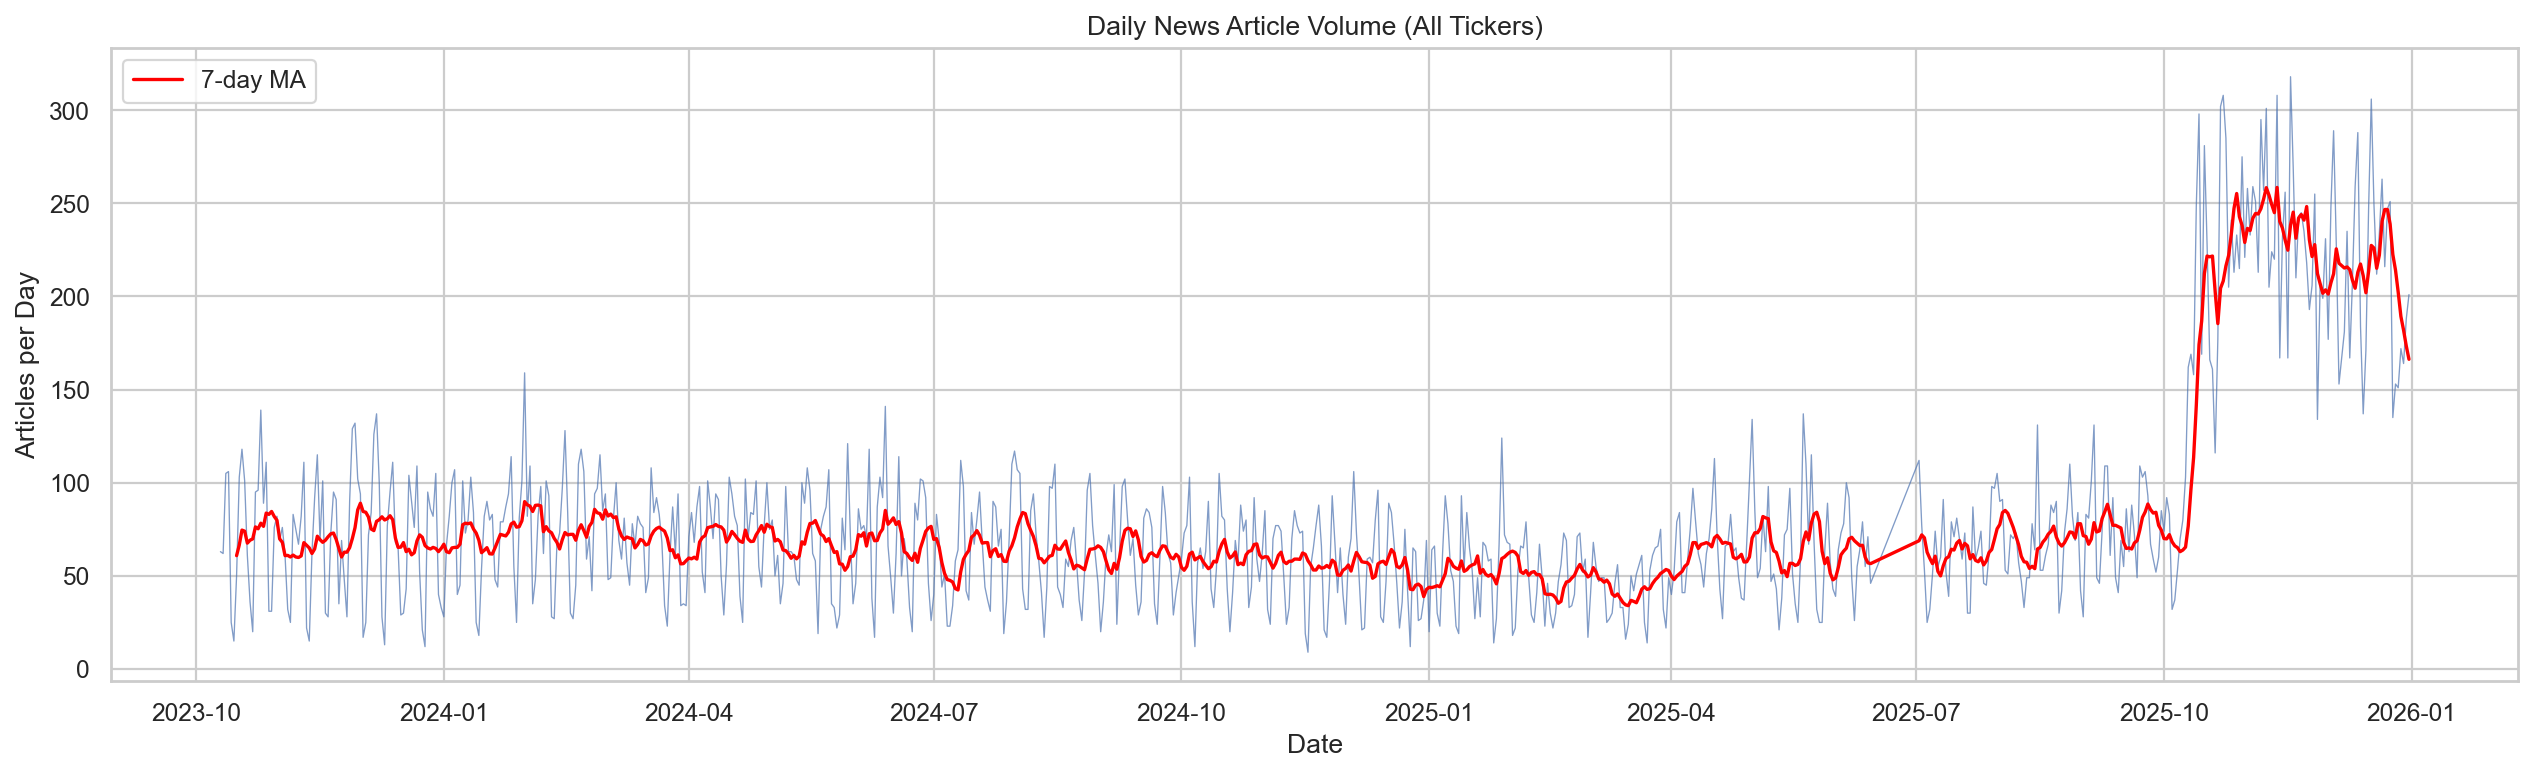

Average articles per day: 80.5
Max articles in a day: 318 (2025-11-17)
Min articles in a day: 9 (2024-11-17)


In [7]:
# Daily article volume across all tickers
daily_counts = news.groupby("date_only").size()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_counts.index, daily_counts.values, linewidth=0.6, alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Articles per Day")
ax.set_title("Daily News Article Volume (All Tickers)")

# Add 7-day rolling average
rolling = daily_counts.rolling(7).mean()
ax.plot(rolling.index, rolling.values, color="red", linewidth=1.5, label="7-day MA")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Average articles per day: {daily_counts.mean():.1f}")
print(f"Max articles in a day: {daily_counts.max()} ({daily_counts.idxmax()})")
print(f"Min articles in a day: {daily_counts.min()} ({daily_counts.idxmin()})")

C:\Users\Alasteir\AppData\Local\Temp\ipykernel_32700\2433916839.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news["year_month"] = news["date"].dt.to_period("M")


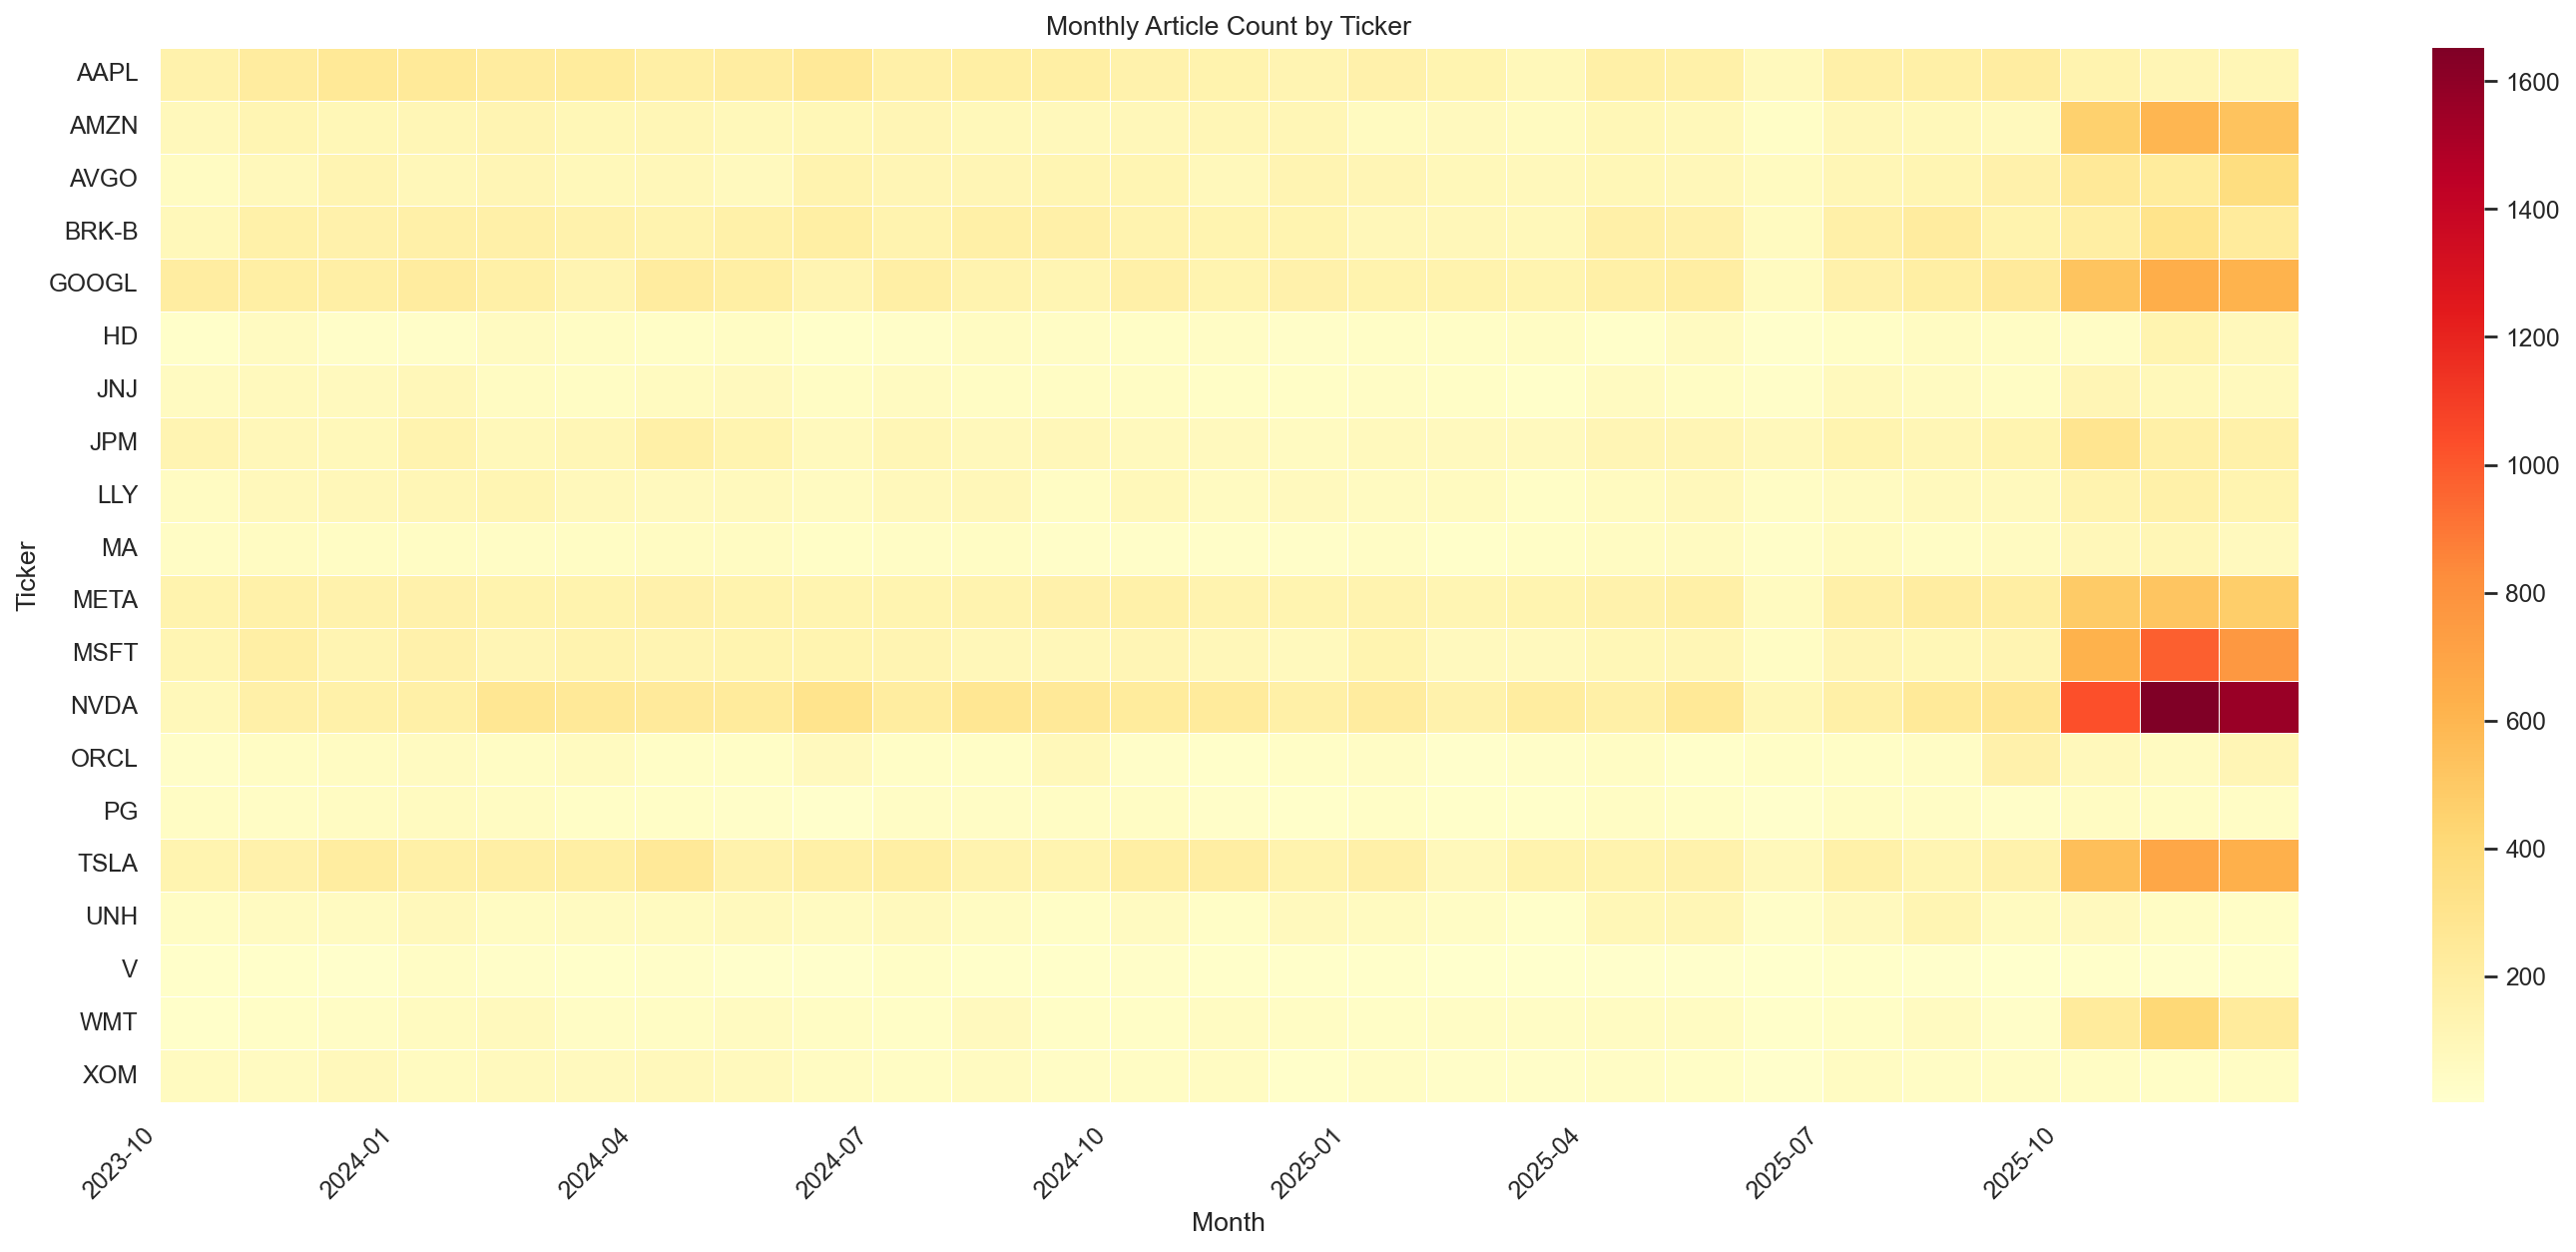

In [8]:
# Monthly article volume by ticker (heatmap)
news["year_month"] = news["date"].dt.to_period("M")
monthly_ticker = news.groupby(["year_month", "ticker"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(monthly_ticker.T, cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_title("Monthly Article Count by Ticker")
ax.set_xlabel("Month")
ax.set_ylabel("Ticker")

# Reduce x-tick clutter
tick_positions = range(0, len(monthly_ticker.index), 3)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(monthly_ticker.index[i]) for i in tick_positions], rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 5. Source Distribution

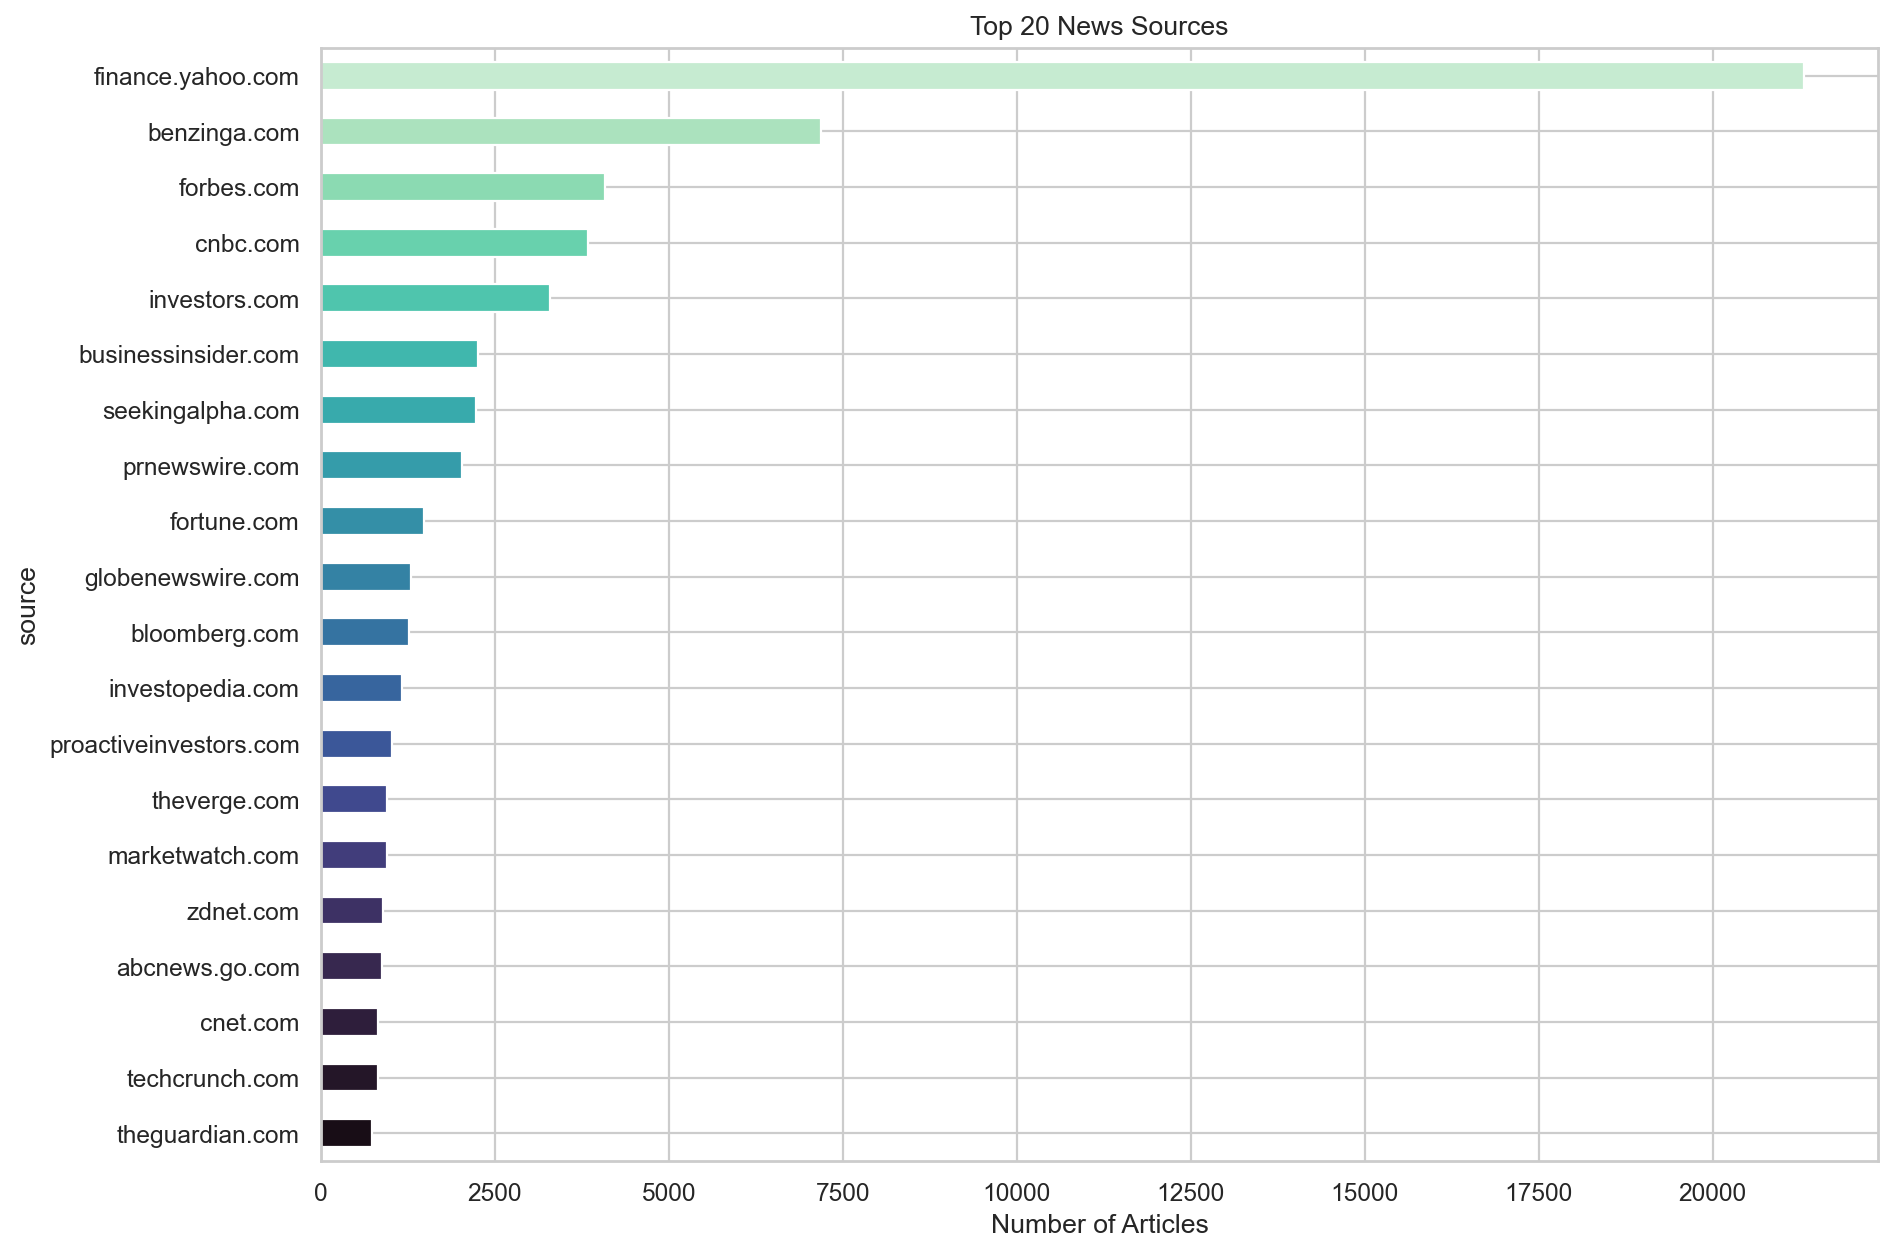


Total unique sources: 65
Top 10 sources account for 76.5% of all articles


In [9]:
# Top 20 news sources
source_counts = news["source"].value_counts()
top_sources = source_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
top_sources.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("mako", len(top_sources)))
ax.set_xlabel("Number of Articles")
ax.set_title("Top 20 News Sources")
plt.tight_layout()
plt.show()

print(f"\nTotal unique sources: {news['source'].nunique()}")
print(f"Top 10 sources account for {source_counts.head(10).sum() / len(news) * 100:.1f}% of all articles")

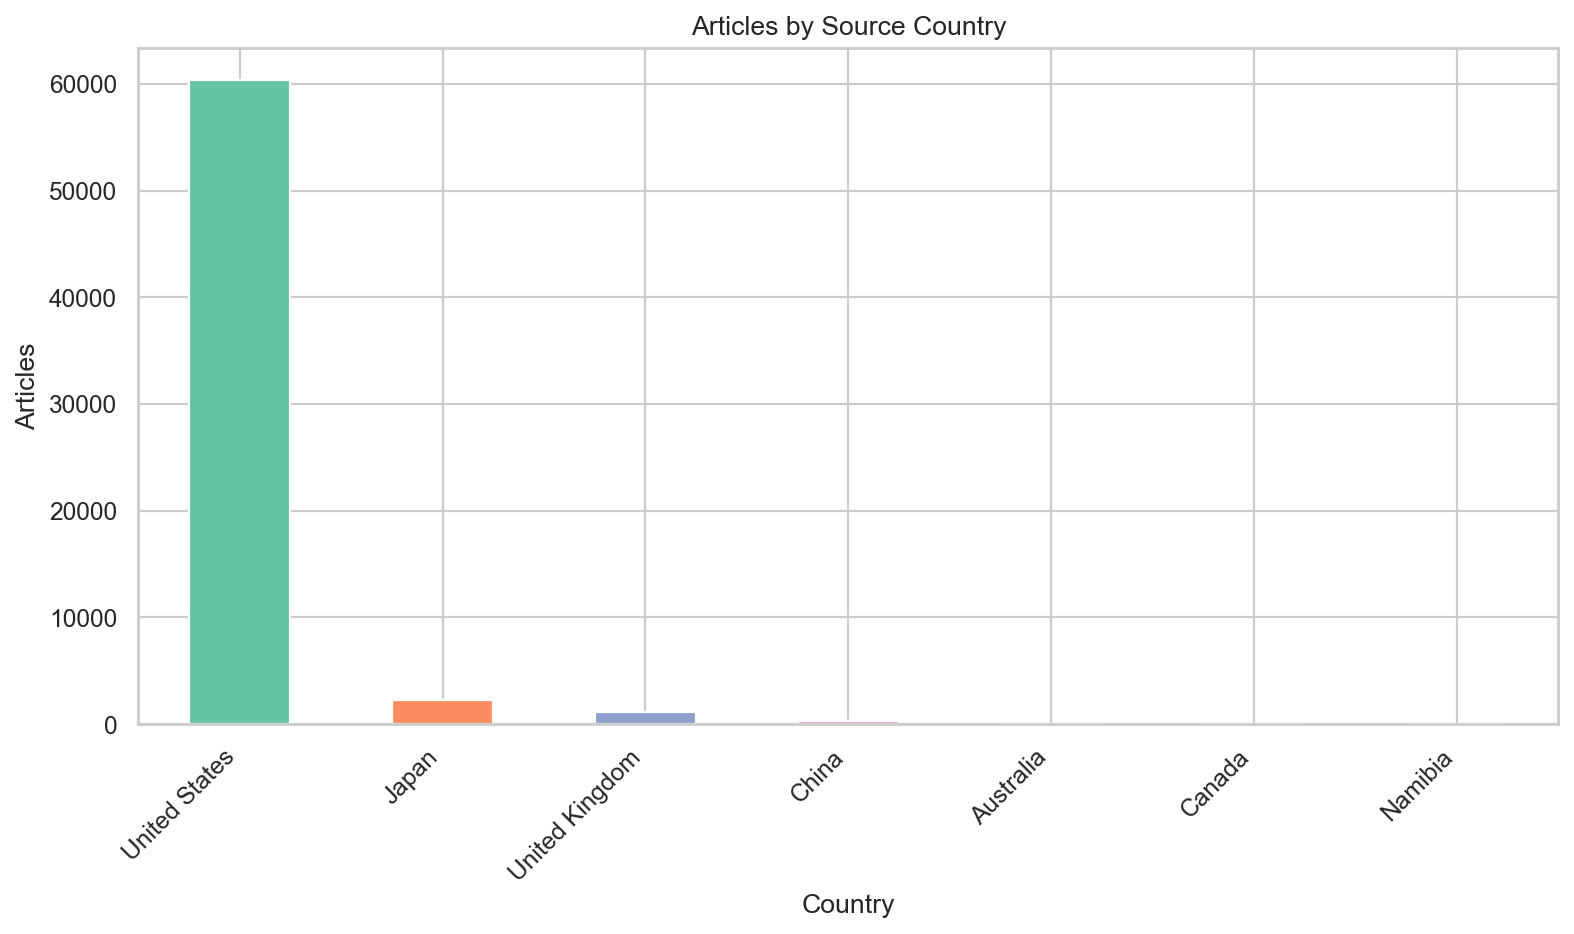

In [10]:
# Source country distribution
country_counts = news["sourcecountry"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
country_counts.plot(kind="bar", ax=ax, color=sns.color_palette("Set2"))
ax.set_xlabel("Country")
ax.set_ylabel("Articles")
ax.set_title("Articles by Source Country")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Headline Length Analysis

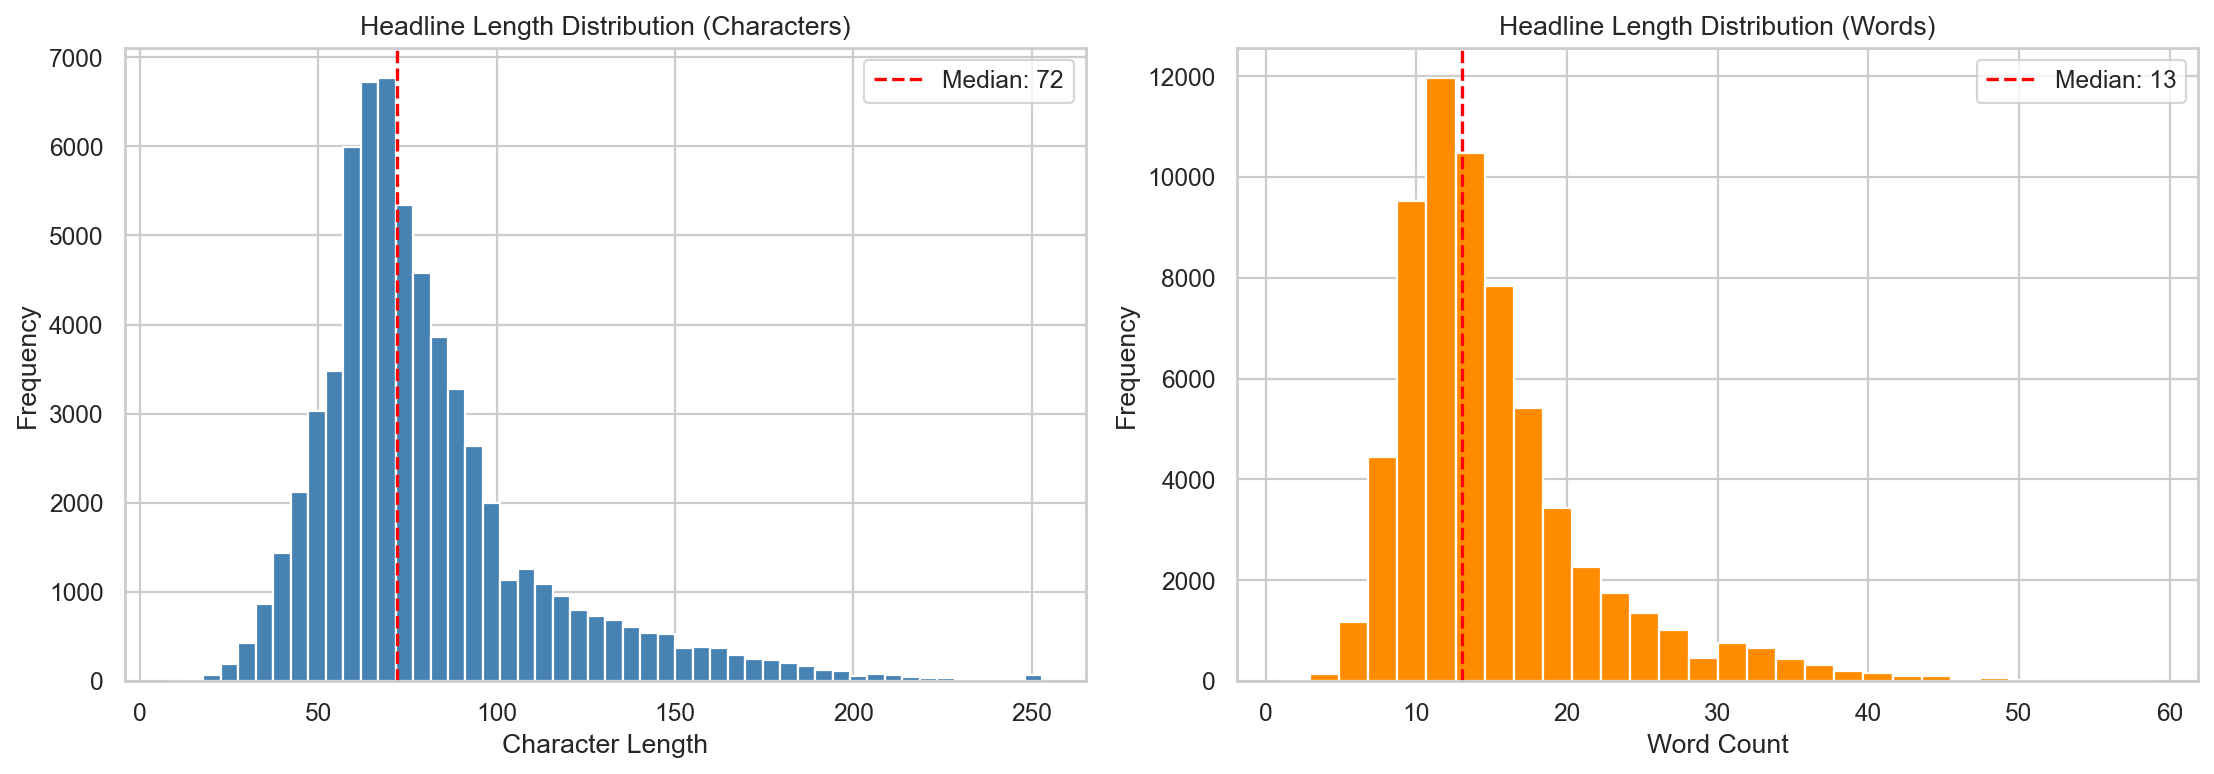

Headline character length - Mean: 80.3, Median: 72, Std: 32.1
Headline word count     - Mean: 14.9, Median: 13, Std: 6.5


In [11]:
news["headline_len"] = news["headline"].astype(str).str.len()
news["headline_word_count"] = news["headline"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(news["headline_len"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Headline Length Distribution (Characters)")
axes[0].axvline(news["headline_len"].median(), color="red", linestyle="--", label=f"Median: {news['headline_len'].median():.0f}")
axes[0].legend()

axes[1].hist(news["headline_word_count"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Headline Length Distribution (Words)")
axes[1].axvline(news["headline_word_count"].median(), color="red", linestyle="--", label=f"Median: {news['headline_word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_news_headline_length.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Headline character length - Mean: {news['headline_len'].mean():.1f}, Median: {news['headline_len'].median():.0f}, Std: {news['headline_len'].std():.1f}")
print(f"Headline word count     - Mean: {news['headline_word_count'].mean():.1f}, Median: {news['headline_word_count'].median():.0f}, Std: {news['headline_word_count'].std():.1f}")

## 7. Language Distribution

In [12]:
lang_counts = news["language"].value_counts()

print("Language distribution:")
for lang, count in lang_counts.items():
    print(f"  {lang}: {count:,} ({count/len(news)*100:.1f}%)")

if len(lang_counts) > 1:
    fig, ax = plt.subplots(figsize=(8, 5))
    lang_counts.plot(kind="bar", ax=ax, color=sns.color_palette("pastel"))
    ax.set_title("Articles by Language")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Language distribution:
  English: 64,069 (100.0%)


## 8. Duplicate and Data Quality Analysis

In [13]:
# Check for duplicate headlines
dup_headlines = news["headline"].duplicated().sum()
dup_full = news.duplicated().sum()

print(f"Duplicate headlines (same text, possibly different dates/tickers): {dup_headlines:,} ({dup_headlines/len(news)*100:.1f}%)")
print(f"Fully duplicate rows: {dup_full:,} ({dup_full/len(news)*100:.1f}%)")

# Headlines appearing across multiple tickers
headline_ticker_count = news.groupby("headline")["ticker"].nunique()
cross_ticker = headline_ticker_count[headline_ticker_count > 1]
print(f"\nHeadlines appearing for multiple tickers: {len(cross_ticker):,}")

if len(cross_ticker) > 0:
    print("\nSample cross-ticker headlines:")
    for headline in cross_ticker.sort_values(ascending=False).head(5).index:
        tickers = news[news["headline"] == headline]["ticker"].unique()
        print(f"  [{', '.join(tickers)}] {headline[:100]}")

Duplicate headlines (same text, possibly different dates/tickers): 11,329 (17.7%)
Fully duplicate rows: 0 (0.0%)

Headlines appearing for multiple tickers: 7,967

Sample cross-ticker headlines:
  [AAPL, AMZN, AVGO, BRK-B, GOOGL, HD, JNJ, JPM, LLY, MA, META, MSFT, NVDA, ORCL, PG, TSLA, UNH, WMT] 5 Things to Know Before the Stock Market Opens
  [AMZN, AVGO, BRK-B, HD, JNJ, JPM, LLY, META, MSFT, NVDA, ORCL, PG, TSLA, UNH, WMT, XOM] Stock market today : Live updates
  [AAPL, AVGO, BRK-B, GOOGL, HD, JNJ, LLY, MA, META, NVDA, ORCL, PG, UNH, WMT] Jim Cramer top 10 things to watch in the stock market Wednesday
  [AAPL, AVGO, BRK-B, HD, JNJ, LLY, MA, META, MSFT, NVDA, PG, TSLA, WMT] Jim Cramer top 10 things to watch in the stock market Friday
  [AAPL, AMZN, AVGO, GOOGL, HD, LLY, MA, META, MSFT, UNH, V, WMT, XOM] Here are the 3 big things were watching in the stock market this week


## 9. Day-of-Week Distribution

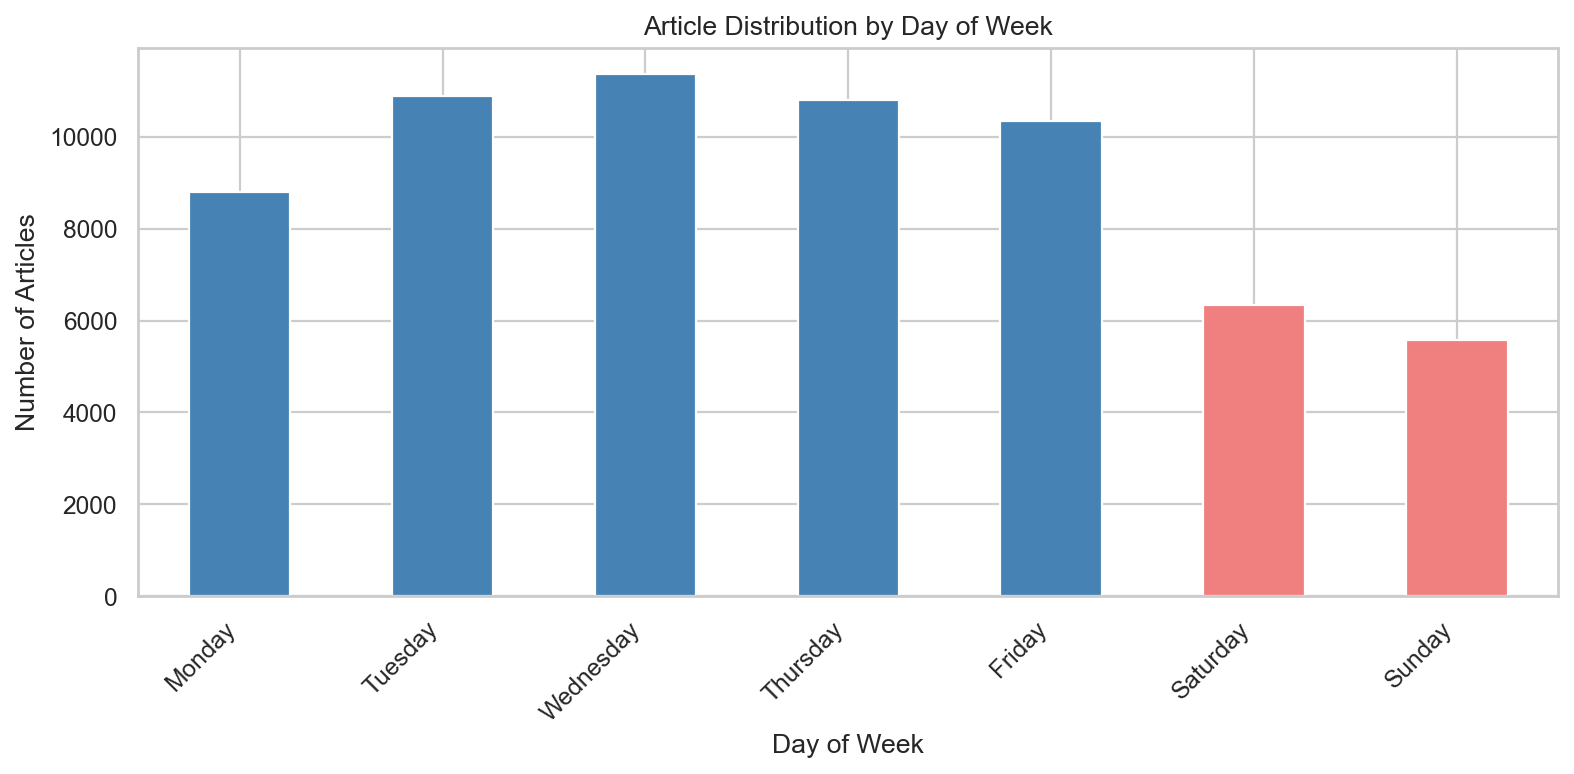

Weekday articles: 52,160 (81.4%)
Weekend articles: 11,909 (18.6%)


In [14]:
news["day_of_week"] = news["date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = news["day_of_week"].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
dow_counts.plot(kind="bar", ax=ax, color=["steelblue"]*5 + ["lightcoral"]*2)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Articles")
ax.set_title("Article Distribution by Day of Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

weekday = dow_counts[:5].sum()
weekend = dow_counts[5:].sum()
print(f"Weekday articles: {weekday:,} ({weekday/len(news)*100:.1f}%)")
print(f"Weekend articles: {weekend:,} ({weekend/len(news)*100:.1f}%)")

## 10. Summary

In [15]:
print("=" * 60)
print("NEWS DATASET EDA SUMMARY")
print("=" * 60)
print(f"Total articles:          {len(news):,}")
print(f"Tickers:                 {news['ticker'].nunique()}")
print(f"Date range:              {news['date'].min().strftime('%Y-%m-%d')} to {news['date'].max().strftime('%Y-%m-%d')}")
print(f"Unique sources:          {news['source'].nunique():,}")
print(f"Languages:               {news['language'].nunique()}")
print(f"Missing headlines:       {news['headline'].isna().sum():,}")
print(f"Duplicate rows:          {news.duplicated().sum():,}")
print(f"Avg headline length:     {news['headline_len'].mean():.0f} chars / {news['headline_word_count'].mean():.0f} words")
print(f"Avg articles per day:    {daily_counts.mean():.1f}")
print("=" * 60)

NEWS DATASET EDA SUMMARY
Total articles:          64,069
Tickers:                 20
Date range:              2023-10-10 to 2025-12-31
Unique sources:          65
Languages:               1
Missing headlines:       0
Duplicate rows:          0
Avg headline length:     80 chars / 15 words
Avg articles per day:    80.5
